In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

# Load the CSV file
df = pd.read_csv('Student-Employability-Datasets.csv')

# Display the first few rows
print(df.head())
# Check data types and missing values
print(df.info())

  Name of Student  GENERAL APPEARANCE  MANNER OF SPEAKING  PHYSICAL CONDITION  \
0       Student 1                   4                   5                   4   
1       Student 2                   4                   4                   4   
2       Student 3                   4                   3                   3   
3       Student 4                   3                   3                   3   
4       Student 5                   4                   4                   3   

   MENTAL ALERTNESS  SELF-CONFIDENCE  ABILITY TO PRESENT IDEAS  \
0                 5                5                         5   
1                 4                4                         4   
2                 3                3                         3   
3                 2                3                         3   
4                 3                4                         4   

   COMMUNICATION SKILLS  Student Performance Rating           CLASS  
0                     5                       

In [2]:
df.drop(['Name of Student', 'CLASS'], axis=1, inplace=True)

In [4]:
# Calculate the mean
mean_value = df['GENERAL APPEARANCE'].mean()

# Fill the NaNs and assign the result directly back to the column
df['GENERAL APPEARANCE'] = df['GENERAL APPEARANCE'].fillna(mean_value)

In [5]:
# Example for One-Hot Encoding (for nominal categories)
df = pd.get_dummies(df, columns=['PHYSICAL CONDITION'], drop_first=True)

In [6]:
X = df.drop('Student Performance Rating', axis=1) # Features
y = df['Student Performance Rating']             # Target

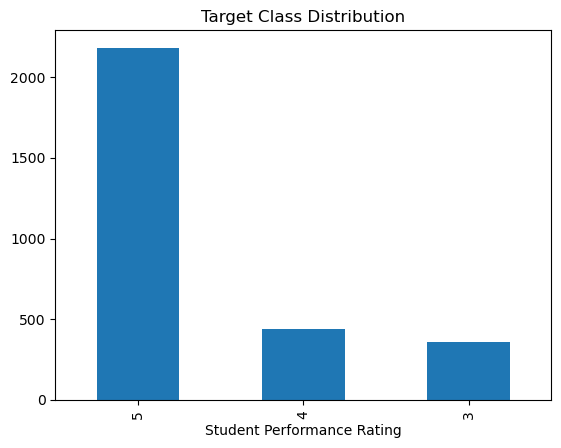

In [7]:
# Visualize the distribution of the target variable
import matplotlib.pyplot as plt
y.value_counts().plot(kind='bar', title='Target Class Distribution')
plt.show()

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

In [9]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

# Fit scaler only on training data, then transform both
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [10]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

# Fit scaler only on training data, then transform both
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [11]:
from sklearn.ensemble import RandomForestClassifier
# Instantiate the model
model = RandomForestClassifier(n_estimators=100, random_state=42)

# Train the model
model.fit(X_train_scaled, y_train)

RandomForestClassifier(random_state=42)

In [12]:
y_pred = model.predict(X_test_scaled)

In [13]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Accuracy
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")

# Detailed metrics (Precision, Recall, F1-score)
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Confusion Matrix
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.8469

Classification Report:
              precision    recall  f1-score   support

           3       0.85      0.58      0.69       108
           4       0.75      0.58      0.66       132
           5       0.86      0.94      0.90       655

    accuracy                           0.85       895
   macro avg       0.82      0.70      0.75       895
weighted avg       0.84      0.85      0.84       895


Confusion Matrix:
[[ 63   0  45]
 [  0  77  55]
 [ 11  26 618]]


In [17]:
# Assuming X.columns contains all features:
# ['GENERAL APPEARANCE', 'MANNER OF SPEAKING', 'MENTAL ALERTNESS', 
#  'SELF-CONFIDENCE', 'ABILITY TO PRESENT IDEAS', 'COMMUNICATION SKILLS', 
#  'PHYSICAL CONDITION_3', 'PHYSICAL CONDITION_4', 'PHYSICAL CONDITION_5', ...]

new_student_data = pd.DataFrame({
    # 1. Base Features (The ones the error message says are MISSING):
    'GENERAL APPEARANCE': [4], 
    'MANNER OF SPEAKING': [5],
    'MENTAL ALERTNESS': [3],
    'SELF-CONFIDENCE': [4],
    'ABILITY TO PRESENT IDEAS': [5],
    'COMMUNICATION SKILLS': [5],

    # 2. Encoded Features (The ones that caused errors previously, now set correctly):
    'PHYSICAL CONDITION_3': [0],
    'PHYSICAL CONDITION_4': [1], # Example: This student had Condition 4
    'PHYSICAL CONDITION_5': [0]  # MUST include all categories, set to 0 if not present
    # ... include any other one-hot encoded columns (e.g., from 'CLASS' if you kept it)

}, index=[0])

# This step now reorders the complete DataFrame to match the training column order:
new_student_data = new_student_data[X.columns] 

# The rest of the prediction steps (scaling and prediction) should now run.
# new_data_scaled = scaler.transform(new_student_data)
# final_prediction = model.predict(new_data_scaled)

In [18]:
# Train Score Check
y_train_pred = model.predict(X_train_scaled)
train_accuracy = accuracy_score(y_train, y_train_pred)

# Test Score Check (from Step 5)
test_accuracy = accuracy_score(y_test, y_pred)

print(f"Training Accuracy: {train_accuracy:.4f}")
print(f"Testing Accuracy:  {test_accuracy:.4f}")

Training Accuracy: 0.8486
Testing Accuracy:  0.8469
